<a href="https://colab.research.google.com/github/Swasthika3/DL-24BAD121-/blob/main/EXNO_5_DL_24BAD121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK A — DATASET PREPARATION**

In [3]:
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Name: Swasthika M")
print("Roll No: 24BAD121")

# Load Tiny Shakespeare dataset
# dataset = load_dataset("tiny_shakespeare") # Original line

# Fix: Download and load the text file directly
path_to_file = tf.keras.utils.get_file('tinyshakespeare.txt', 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt')

with open(path_to_file, 'rb') as f:
    text = f.read().decode(encoding='utf-8')

print("\nDataset loaded successfully")
print("Number of characters:", len(text))
print("\nSample text:\n")
print(text[:1000])

# Convert to lowercase
text = text.lower()

# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("\nVocabulary size:", total_words)

# Generate input sequences
sequences = []

for line in text.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        sequences.append(token_list[:i+1])

print("Total sequences:", len(sequences))

# Padding
max_sequence_len = max(len(seq) for seq in sequences)

sequences = pad_sequences(
    sequences,
    maxlen=max_sequence_len,
    padding="pre"
)

sequences = np.array(sequences)

# Input and target
X = sequences[:, :-1]
y = sequences[:, -1]

# Train-validation split
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]

print("\nMaximum sequence length:", max_sequence_len)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Data preparation completed successfully.")

Name: Swasthika M
Roll No: 24BAD121
1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Dataset loaded successfully
Number of characters: 1115394

Sample text:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
suffera

**TASK B — IMPLEMENTING THE RNN MODEL**

In [4]:
# EXPERIMENT NO: 5
# Name: Swasthika M
# Roll No: 24BAD121
# RNN Text Generation - Task B

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

print("Name: Swasthika M")
print("Roll No: 24BAD121")

model = Sequential([
    Embedding(total_words, 64, input_length=X_train.shape[1]),
    SimpleRNN(128),
    Dense(total_words, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Name: Swasthika M
Roll No: 24BAD121


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**TASK C — TRAINING AND PERFORMANCE EVALUATION**

Epoch 1/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 107s 97ms/step - accuracy: 0.0466 - loss: 6.8061 - val_accuracy: 0.0617 - val_loss: 6.5842
Epoch 2/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 113s 105ms/step - accuracy: 0.0852 - loss: 6.1248 - val_accuracy: 0.0812 - val_loss: 6.4979
Epoch 3/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 129s 93ms/step - accuracy: 0.0998 - loss: 5.7849 - val_accuracy: 0.0865 - val_loss: 6.4815
Epoch 4/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 140s 92ms/step - accuracy: 0.1122 - loss: 5.5148 - val_accuracy: 0.0879 - val_loss: 6.5325
Epoch 5/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 98s 92ms/step - accuracy: 0.1208 - loss: 5.2826 - val_accuracy: 0.0906 - val_loss: 6.6052

Name: Swasthika M
Roll No: 24BAD121

Training Accuracy: 13.74 %
Validation Accuracy: 9.06 %
Training Loss: 4.9331
Validation Loss: 6.6052


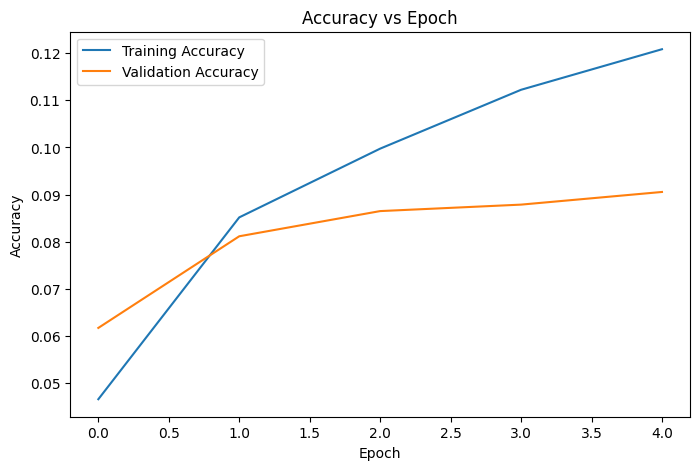

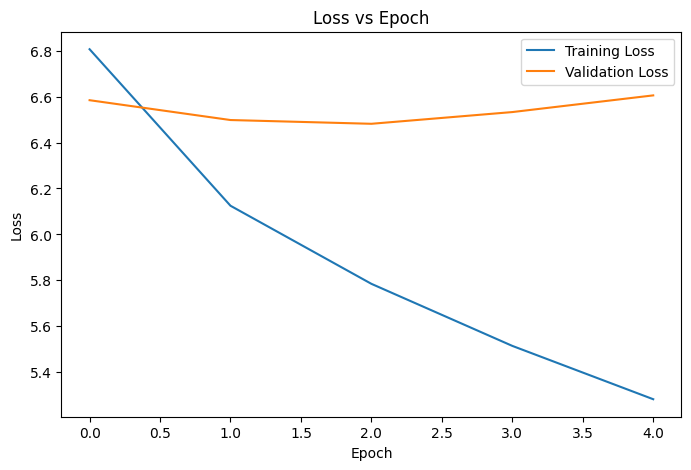

In [5]:
# EXPERIMENT NO: 5
# Name: Swasthika M
# Roll No: 24BAD121
# RNN Text Generation - Task C

import matplotlib.pyplot as plt

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128,
    verbose=1
)

# Final performance
train_loss, train_accuracy = model.evaluate(
    X_train, y_train, verbose=0
)

val_loss, val_accuracy = model.evaluate(
    X_val, y_val, verbose=0
)

print("\nName: Swasthika M")
print("Roll No: 24BAD121")

print("\nTraining Accuracy:", round(train_accuracy * 100, 2), "%")
print("Validation Accuracy:", round(val_accuracy * 100, 2), "%")
print("Training Loss:", round(train_loss, 4))
print("Validation Loss:", round(val_loss, 4))

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

**TASK D — TEXT GENERATION**

In [6]:
# EXPERIMENT NO: 5
# Name: Swasthika M
# Roll No: 24BAD121
# RNN Text Generation - Task D

def generate_text(seed_text, next_words=20):
    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=X_train.shape[1],
            padding="pre"
        )

        predicted = model.predict(token_list, verbose=0)
        predicted_word_index = np.argmax(predicted, axis=-1)[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        if output_word == "":
            break

        seed_text += " " + output_word

    return seed_text


print("Name: Swasthika M")
print("Roll No: 24BAD121")

seed1 = "to be or not"
seed2 = "the king"
seed3 = "my lord"

print("\nGenerated Text 1:")
print(generate_text(seed1, 20))

print("\nGenerated Text 2:")
print(generate_text(seed2, 20))

print("\nGenerated Text 3:")
print(generate_text(seed3, 20))

Name: Swasthika M
Roll No: 24BAD121

Generated Text 1:
to be or not to make him to the tower and all the world of death and i have done to thee to be

Generated Text 2:
the king of york and i am sure of york and i will not be gone to night to be a man

Generated Text 3:
my lord of york and i am sure of york and i will not be satisfied ' as i will be a
